In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# Prophet import (new name is 'prophet')
from prophet import Prophet

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [16]:
file_2023 = "DATA TABLE-2023- SALE 50.xlsx"
file_2024 = "DATA TABLE-2024- SALE  51.xlsx"
file_2025 = "DATA TABLE-2025- SALE  46- up to November.xlsx"

usecols = ["YEAR", "SALE NO", "ELE1", "GRADE", "PRICE", "QTY"]

df_2023 = pd.read_excel(file_2023, sheet_name="DATA", usecols=usecols)
df_2024 = pd.read_excel(file_2024, sheet_name="DATA", usecols=usecols)
df_2025 = pd.read_excel(file_2025, sheet_name="DATA", usecols=usecols)

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)
print("Raw rows:", df_all.shape)


Raw rows: (1503888, 6)


In [17]:
# =====================
df_all = df_all.dropna(subset=["YEAR","SALE NO","ELE1","GRADE","PRICE","QTY"]).copy()

df_all["SALE NO"] = pd.to_numeric(df_all["SALE NO"], errors="coerce")
df_all["PRICE"]   = pd.to_numeric(df_all["PRICE"], errors="coerce")
df_all["QTY"]     = pd.to_numeric(df_all["QTY"], errors="coerce")

df_all = df_all.dropna(subset=["SALE NO","PRICE","QTY"])
df_all = df_all[df_all["QTY"] > 0]

df_all["ELE1"]  = df_all["ELE1"].astype(str).str.strip().str.title()
df_all["GRADE"] = df_all["GRADE"].astype(str).str.strip().str.upper()

print("Elevations:", df_all["ELE1"].value_counts().to_dict())
print("Unique grades:", df_all["GRADE"].nunique())

Elevations: {'Low': 1018754, 'Medium': 250027, 'High': 235107}
Unique grades: 527


In [18]:
def weighted_avg_price(g):
    return np.average(g["PRICE"], weights=g["QTY"])

weekly = (
    df_all
    .groupby(["YEAR","SALE NO","ELE1","GRADE"], as_index=False)
    .apply(lambda g: pd.Series({
        "avg_price": weighted_avg_price(g),
        "qty_sold":  g["QTY"].sum(),
        "lots":      len(g)
    }))
    .reset_index(drop=True)
)

weekly["SALE NO"] = weekly["SALE NO"].astype(int)
weekly["YEAR"]    = weekly["YEAR"].astype(int)

# Nice week_id for plots
weekly["week_id"] = weekly["YEAR"].astype(str) + "-" + weekly["SALE NO"].astype(str).str.zfill(2)

weekly = weekly.sort_values(["ELE1","GRADE","YEAR","SALE NO"]).reset_index(drop=True)
print("Weekly rows:", weekly.shape)
weekly.head()


Weekly rows: (21730, 8)


,YEAR,SALE NO,ELE1,GRADE,avg_price,qty_sold,lots,week_id
0,2023,7,High,ABBFOSP,12000.0,2.0,1.0,2023-07
1,2023,11,High,ABBFOSP,13000.0,1.0,1.0,2023-11
2,2023,13,High,ABBFOSP,22000.0,1.0,1.0,2023-13
3,2023,19,High,ABBFOSP,22000.0,2.0,1.0,2023-19
4,2023,22,High,ABBFOSP,22000.0,10.0,2.0,2023-22


In [19]:
def add_ds_from_year_sale(df):
    df = df.sort_values(["YEAR","SALE NO"]).copy()
    start_of_year = pd.to_datetime(df["YEAR"].astype(str) + "-01-01")
    df["ds"] = start_of_year + pd.to_timedelta((df["SALE NO"] - 1) * 7, unit="D")
    return df


In [20]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100)
    return mae, rmse, mape


In [21]:
def train_prophet_one_series(df_series, test_weeks=52, cps=0.1):
    df_series = add_ds_from_year_sale(df_series)

    # Prophet expects columns ds, y
    dfp = df_series[["ds", "avg_price", "qty_sold", "lots", "week_id"]].copy()
    dfp = dfp.rename(columns={"avg_price": "y"})
    dfp = dfp.dropna(subset=["ds","y"]).sort_values("ds")

    if len(dfp) < (test_weeks + 30):
        return None

    train = dfp.iloc[:-test_weeks].copy()
    test  = dfp.iloc[-test_weeks:].copy()

    # Prophet model
    m = Prophet(
        yearly_seasonality=True,      # weekly data → yearly pattern matters
        weekly_seasonality=False,     # not needed (your data is already weekly)
        daily_seasonality=False,
        changepoint_prior_scale=cps   # controls flexibility; 0.05–0.2 typical
    )

    # OPTIONAL: If you want Prophet to use extra regressors (later):
    # m.add_regressor("qty_sold")
    # m.add_regressor("lots")

    m.fit(train[["ds", "y"]])

    fcst = m.predict(test[["ds"]])
    yhat = fcst["yhat"].values

    mae, rmse, mape = calc_metrics(test["y"].values, yhat)

    return {
        "model": m,
        "train": train,
        "test": test,
        "forecast": fcst,
        "metrics": {"mae": mae, "rmse": rmse, "mape": mape}
    }


In [22]:
ELEVATIONS = ["Low", "Medium", "High"]  # make sure these match your ELE1 values
TEST_WEEKS = 52

prophet_models = {}
rows = []

for elev in ELEVATIONS:
    grades = sorted(weekly.loc[weekly["ELE1"] == elev, "GRADE"].unique())

    print("\n===============================")
    print(f"Training Prophet: {elev} | grades={len(grades)}")
    print("===============================")

    for grade in grades:
        df_s = weekly[(weekly["ELE1"] == elev) & (weekly["GRADE"] == grade)].copy()
        out = train_prophet_one_series(df_s, test_weeks=TEST_WEEKS, cps=0.1)

        if out is None:
            continue

        prophet_models[(elev, grade)] = out
        m = out["metrics"]
        rows.append([elev, grade, m["mae"], m["rmse"], m["mape"]])

        print(f"{elev:6s} {grade:6s} | MAE={m['mae']:.2f} RMSE={m['rmse']:.2f} MAPE={m['mape']:.2f}%")

df_prophet_results = pd.DataFrame(rows, columns=["Elevation","Grade","MAE","RMSE","MAPE_%"])
df_prophet_results = df_prophet_results.sort_values(["Elevation","MAPE_%"]).reset_index(drop=True)
df_prophet_results.head(500)

17:45:02 - cmdstanpy - INFO - Chain [1] start processing



Training Prophet: Low | grades=134


17:45:03 - cmdstanpy - INFO - Chain [1] done processing
17:45:03 - cmdstanpy - INFO - Chain [1] start processing


Low    BM     | MAE=31.41 RMSE=40.76 MAPE=3.79%


17:45:03 - cmdstanpy - INFO - Chain [1] done processing
17:45:03 - cmdstanpy - INFO - Chain [1] start processing


...

17:45:57 - cmdstanpy - INFO - Chain [1] done processing
17:45:57 - cmdstanpy - INFO - Chain [1] start processing


High   SILVER TIP | MAE=3715.08 RMSE=4701.26 MAPE=17.00%


17:45:57 - cmdstanpy - INFO - Chain [1] done processing


High   WHITE TEA | MAE=4470.87 RMSE=5575.19 MAPE=60.49%


,Elevation,Grade,MAE,RMSE,MAPE_%
0,High,BM,35.069852,47.137718,4.389683
1,High,PEK,76.527507,99.937696,6.151949
2,High,BOP1A,59.029166,71.459703,6.713757
3,High,PF1,94.844213,119.136126,8.717658
4,High,FGS1,86.244115,108.779036,9.045903
...,...,...,...,...,...
112,Medium,PEK1,554.225475,608.625330,36.810925
113,Medium,FBOPFEXSP,739.958194,824.670669,46.037453
114,Medium,FBOPFEXSP1,915.005721,987.298344,50.004785
115,Medium,FBOPFSP,865.722648,900.110685,60.544028


In [23]:
def plot_prophet_test(elev, grade):
    key = (elev, grade)
    if key not in prophet_models:
        print("Model not found:", key)
        return

    out = prophet_models[key]
    test = out["test"]
    fcst = out["forecast"]

    y_true = test["y"].values
    y_pred = fcst["yhat"].values
    y_lo   = fcst["yhat_lower"].values
    y_hi   = fcst["yhat_upper"].values

    plt.figure(figsize=(12,4))
    plt.plot(test["week_id"], y_true, label="Actual", linewidth=2)
    plt.plot(test["week_id"], y_pred, label="Prophet Predicted", linewidth=2)
    plt.fill_between(test["week_id"], y_lo, y_hi, alpha=0.15, label="Uncertainty interval")
    plt.title(f"{elev} elevation – {grade}: Prophet Test Forecast ({TEST_WEEKS} weeks)")
    plt.ylabel("Avg Price (LKR)")
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

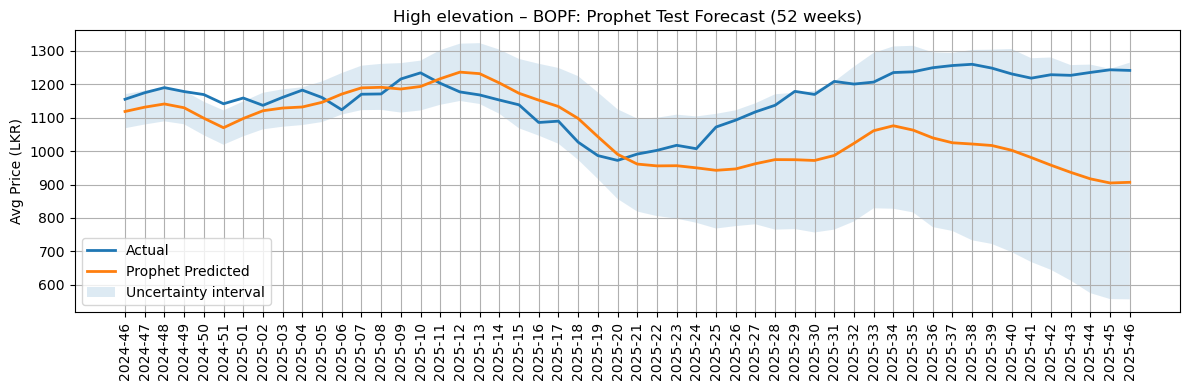

In [24]:
plot_prophet_test("High", "BOPF")

In [25]:
def predict_next_week_prophet(elev, grade):
    key = (elev, grade)
    if key not in prophet_models:
        raise KeyError(f"No Prophet model for {key}")

    out = prophet_models[key]
    m = out["model"]

    # Get last available ds for that series
    df_s = weekly[(weekly["ELE1"] == elev) & (weekly["GRADE"] == grade)].copy()
    df_s = add_ds_from_year_sale(df_s).sort_values("ds")
    last_ds = df_s["ds"].iloc[-1]
    next_ds = last_ds + pd.Timedelta(days=7)

    future = pd.DataFrame({"ds": [next_ds]})
    fcst = m.predict(future)

    return {
        "elevation": elev,
        "grade": grade,
        "last_ds": last_ds,
        "next_ds": next_ds,
        "yhat": float(fcst["yhat"].iloc[0]),
        "yhat_lower": float(fcst["yhat_lower"].iloc[0]),
        "yhat_upper": float(fcst["yhat_upper"].iloc[0]),
    }


In [26]:
print(predict_next_week_prophet("High", "BOPF"))

{'elevation': 'High', 'grade': 'BOPF', 'last_ds': Timestamp('2025-11-12 00:00:00'), 'next_ds': Timestamp('2025-11-19 00:00:00'), 'yhat': 920.1276583504066, 'yhat_lower': 872.2901263251445, 'yhat_upper': 968.7726092678541}


In [27]:
import pickle

ELEVATIONS = ["Low", "Medium", "High"]

for elev in ELEVATIONS:
    elev_models = {
        grade: out["model"]
        for (e, grade), out in prophet_models.items()
        if e == elev
    }

    fname = f"{elev.lower()}_elevation_prophet_models.pkl"
    with open(fname, "wb") as f:
        pickle.dump(elev_models, f)

    print(f"Saved {len(elev_models)} Prophet models -> {fname}")


Saved 34 Prophet models -> low_elevation_prophet_models.pkl
Saved 39 Prophet models -> medium_elevation_prophet_models.pkl
Saved 44 Prophet models -> high_elevation_prophet_models.pkl
